Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rows: 5,000
Columns: ['delivery_id', 'date', 'day_of_week', 'month', 'city_zone', 'time_window', 'weather', 'attempt_number', 'driver_experience_yrs', 'package_count', 'weight_kg', 'distance_km', 'stops_before_this', 'traffic_index', 'delivery_success', 'delay_minutes']

Missing values:
delivery_id                 0
date                        0
day_of_week                 0
month                       0
city_zone                   0
time_window                 0
weather                     0
attempt_number              0
driver_experience_yrs       0
package_count               0
weight_kg                   0
distance_km                 0
stops_before_this           0
traffic_index               0
delivery_success            0
delay_minutes            2001
dtype: int64

--- Overall Summary ---
Total deliveries:  5,000
Successful:        2,999 (60.0%)
Failed:

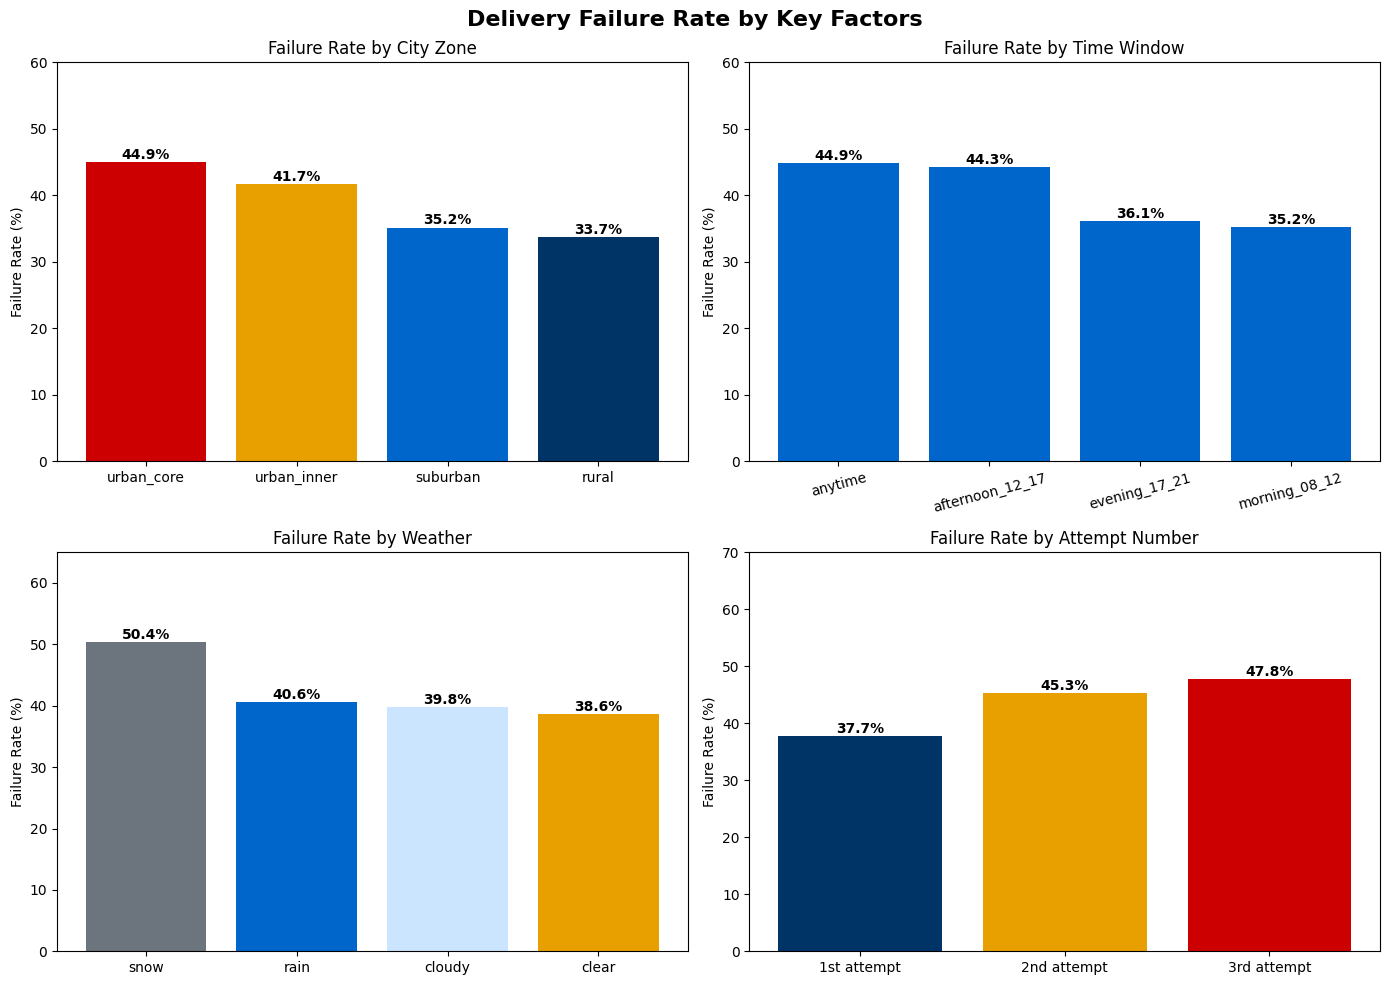

✓ Chart saved: eda_failure_factors.png


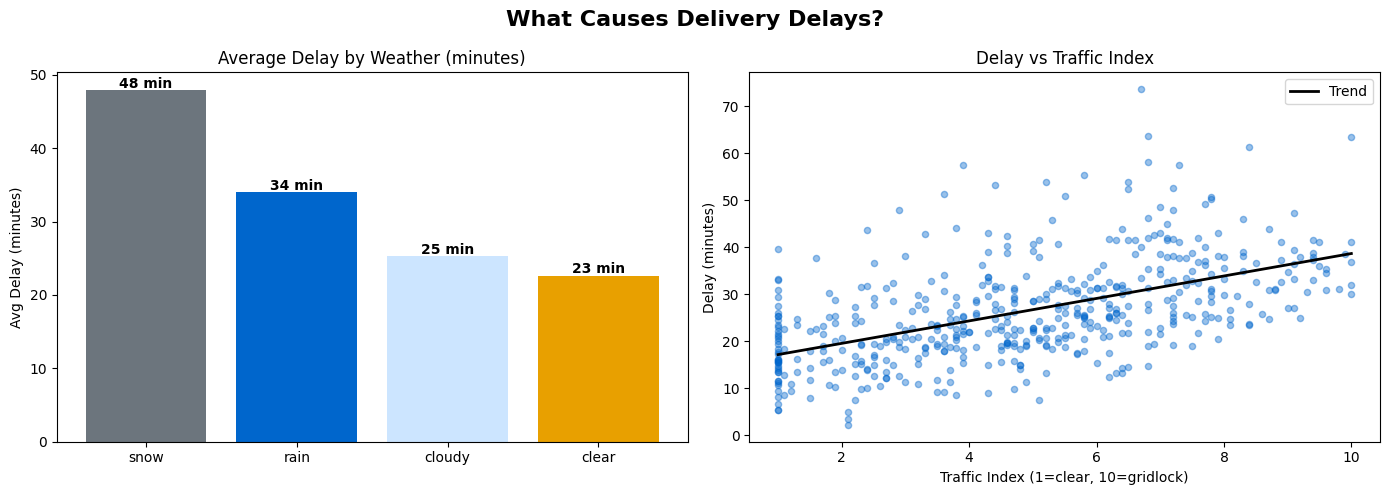

✓ Chart saved: eda_delay_drivers.png


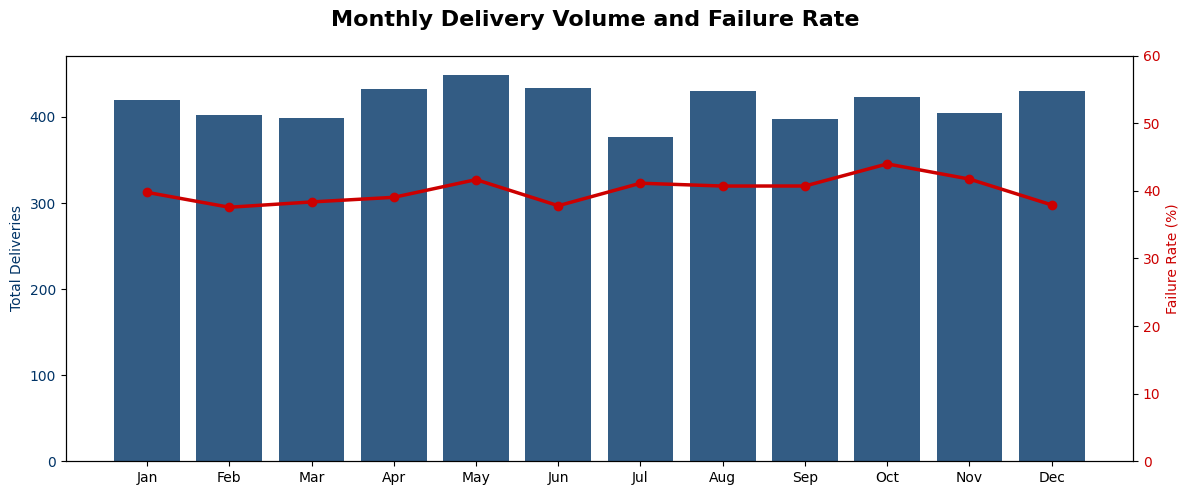

✓ Chart saved: eda_monthly_trend.png

KEY FINDINGS

1. Overall failure rate is 40.0% — meaning 4 in 10
   deliveries fail on the first attempt.

2. Urban core has the highest failure rate (44.9%)
   because customers are less likely to be home during office hours.

3. Vague time windows ("anytime") lead to 44.9% failure —
   customers don't know when to expect the driver.

4. Snow increases failure by 11.8 percentage points
   compared to clear weather.

5. By the 3rd delivery attempt, failure rate jumps to 47.8% —
   repeat attempts are a major cost driver.

6. Traffic index is the strongest predictor of delays.
   High traffic = longer delays, even when delivery succeeds.



In [3]:
# ============================================================
# Last Mile Delivery - Exploratory Data Analysis (EDA)
# ============================================================
# Goal: Understand the data before building any model.
# We answer 4 simple business questions with charts.
#
# Question 1: What is our overall delivery failure rate?
# Question 2: Which factors cause the most failures?
# Question 3: What causes delays?
# Question 4: Are there any trends over time?
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load the data ---

df = pd.read_csv("/content/drive/MyDrive/last_mile_project/data/last_mile_deliveries.csv")
df["date"] = pd.to_datetime(df["date"])

print(f"Rows: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")


# ============================================================
# QUESTION 1: What is our overall delivery failure rate?
# ============================================================

total = len(df)
failed = (df["delivery_success"] == 0).sum()
succeeded = (df["delivery_success"] == 1).sum()

print("\n--- Overall Summary ---")
print(f"Total deliveries:  {total:,}")
print(f"Successful:        {succeeded:,} ({succeeded/total:.1%})")
print(f"Failed:            {failed:,}  ({failed/total:.1%})")
print(f"Avg delay (when delivered): {df['delay_minutes'].mean():.1f} minutes")


# ============================================================
# QUESTION 2: Which factors cause the most failures?
# ============================================================
# We look at failure rate broken down by zone, time window,
# weather, and attempt number.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Delivery Failure Rate by Key Factors", fontsize=16, fontweight="bold")

def failure_rate(series):
    """Helper: calculates % of failed deliveries in a group."""
    return (series == 0).mean() * 100


# --- Chart 1: Failure rate by city zone ---

zone_failure = df.groupby("city_zone")["delivery_success"].apply(failure_rate).sort_values(ascending=False)
axes[0, 0].bar(zone_failure.index, zone_failure.values, color=["#CC0000", "#E8A000", "#0066CC", "#003366"])
axes[0, 0].set_title("Failure Rate by City Zone")
axes[0, 0].set_ylabel("Failure Rate (%)")
axes[0, 0].set_ylim(0, 60)
for i, v in enumerate(zone_failure.values):
    axes[0, 0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")


# --- Chart 2: Failure rate by time window ---

window_failure = df.groupby("time_window")["delivery_success"].apply(failure_rate).sort_values(ascending=False)
axes[0, 1].bar(window_failure.index, window_failure.values, color="#0066CC")
axes[0, 1].set_title("Failure Rate by Time Window")
axes[0, 1].set_ylabel("Failure Rate (%)")
axes[0, 1].set_ylim(0, 60)
axes[0, 1].tick_params(axis="x", rotation=15)
for i, v in enumerate(window_failure.values):
    axes[0, 1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")


# --- Chart 3: Failure rate by weather ---

weather_failure = df.groupby("weather")["delivery_success"].apply(failure_rate).sort_values(ascending=False)
colors = {"snow": "#6C757D", "rain": "#0066CC", "cloudy": "#CCE5FF", "clear": "#E8A000"}
bar_colors = [colors[w] for w in weather_failure.index]
axes[1, 0].bar(weather_failure.index, weather_failure.values, color=bar_colors)
axes[1, 0].set_title("Failure Rate by Weather")
axes[1, 0].set_ylabel("Failure Rate (%)")
axes[1, 0].set_ylim(0, 65)
for i, v in enumerate(weather_failure.values):
    axes[1, 0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")


# --- Chart 4: Failure rate by attempt number ---

attempt_failure = df.groupby("attempt_number")["delivery_success"].apply(failure_rate)
axes[1, 1].bar(["1st attempt", "2nd attempt", "3rd attempt"], attempt_failure.values, color=["#003366", "#E8A000", "#CC0000"])
axes[1, 1].set_title("Failure Rate by Attempt Number")
axes[1, 1].set_ylabel("Failure Rate (%)")
axes[1, 1].set_ylim(0, 70)
for i, v in enumerate(attempt_failure.values):
    axes[1, 1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")


plt.tight_layout()
plt.savefig("/content/drive/MyDrive/last_mile_project/data/eda_failure_factors.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved: eda_failure_factors.png")


# ============================================================
# QUESTION 3: What causes delays?
# ============================================================
# We only look at SUCCESSFUL deliveries here.
# A failed delivery has no delay — it just didn't happen.

success_df = df[df["delivery_success"] == 1].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("What Causes Delivery Delays?", fontsize=16, fontweight="bold")


# --- Chart 5: Average delay by weather ---

avg_delay_weather = success_df.groupby("weather")["delay_minutes"].mean().sort_values(ascending=False)
axes[0].bar(avg_delay_weather.index, avg_delay_weather.values, color=["#6C757D", "#0066CC", "#CCE5FF", "#E8A000"])
axes[0].set_title("Average Delay by Weather (minutes)")
axes[0].set_ylabel("Avg Delay (minutes)")
for i, v in enumerate(avg_delay_weather.values):
    axes[0].text(i, v + 0.3, f"{v:.0f} min", ha="center", fontweight="bold")


# --- Chart 6: Delay vs traffic index (scatter) ---
# We take a sample of 500 points so the chart stays readable

sample = success_df.sample(500, random_state=42)
axes[1].scatter(sample["traffic_index"], sample["delay_minutes"], alpha=0.4, color="#0066CC", s=20)
axes[1].set_title("Delay vs Traffic Index")
axes[1].set_xlabel("Traffic Index (1=clear, 10=gridlock)")
axes[1].set_ylabel("Delay (minutes)")

# Add a trend line

z = np.polyfit(sample["traffic_index"], sample["delay_minutes"], 1)
p = np.poly1d(z)
x_line = np.linspace(1, 10, 100)
axes[1].plot(x_line, p(x_line), color="black", linewidth=2, label="Trend")
axes[1].legend()


plt.tight_layout()
plt.savefig("/content/drive/MyDrive/last_mile_project/data/eda_delay_drivers.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved: eda_delay_drivers.png")


# ============================================================
# QUESTION 4: Are there any trends over time?
# ============================================================

monthly = df.groupby("month").agg(
    total_deliveries=("delivery_id", "count"),
    failure_rate=("delivery_success", lambda x: (x == 0).mean() * 100)
).reset_index()

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly["month_name"] = monthly["month"].apply(lambda x: month_names[x - 1])

fig, ax1 = plt.subplots(figsize=(12, 5))
fig.suptitle("Monthly Delivery Volume and Failure Rate", fontsize=16, fontweight="bold")

# Bar chart: total deliveries
ax1.bar(monthly["month_name"], monthly["total_deliveries"], color="#003366", alpha=0.8, label="Total Deliveries")
ax1.set_ylabel("Total Deliveries", color="#003366")
ax1.tick_params(axis="y", labelcolor="#003366")

# Line chart: failure rate on second y-axis
ax2 = ax1.twinx()
ax2.plot(monthly["month_name"], monthly["failure_rate"], color="#CC0000", linewidth=2.5, marker="o", label="Failure Rate %")
ax2.set_ylabel("Failure Rate (%)", color="#CC0000")
ax2.tick_params(axis="y", labelcolor="#CC0000")
ax2.set_ylim(0, 60)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/last_mile_project/data/eda_monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved: eda_monthly_trend.png")


# ============================================================
# SUMMARY: Key findings in plain English
# ============================================================

print("\n" + "=" * 55)
print("KEY FINDINGS")
print("=" * 55)

worst_zone = zone_failure.idxmax()
worst_window = window_failure.idxmax()
worst_weather = weather_failure.idxmax()
third_attempt_rate = attempt_failure[3]

print(f"""
1. Overall failure rate is {failed/total:.1%} — meaning 4 in 10
   deliveries fail on the first attempt.

2. Urban core has the highest failure rate ({zone_failure[worst_zone]:.1f}%)
   because customers are less likely to be home during office hours.

3. Vague time windows ("anytime") lead to {window_failure[worst_window]:.1f}% failure —
   customers don't know when to expect the driver.

4. Snow increases failure by {weather_failure['snow'] - weather_failure['clear']:.1f} percentage points
   compared to clear weather.

5. By the 3rd delivery attempt, failure rate jumps to {third_attempt_rate:.1f}% —
   repeat attempts are a major cost driver.

6. Traffic index is the strongest predictor of delays.
   High traffic = longer delays, even when delivery succeeds.
""")